# 📘 Day 31 — KNN: Implementation & Scaling Impact

**Author:** Sahil-K-Y 
**Phase:** 3 — Tree Models & SVM 
**Date:** Day 031 of 214-Day AI/ML Roadmap

---
## 📌 Overview

Today we go deeper into KNN implementation details — building proper **sklearn Pipelines**, understanding the **dramatic impact of scaling**, exploring **distance-weighted KNN**, and applying KNN for **regression** tasks.

### 🎯 Learning Objectives
- Build **production-ready KNN pipelines** with scaling
- Deep dive into **StandardScaler vs MinMaxScaler** impact
- Implement **distance-weighted KNN** (`weights='distance'`)
- Apply **KNeighborsRegressor** for continuous predictions
- Use **GridSearchCV** for comprehensive hyperparameter tuning

---
## 🧠 1. KNN Pipeline Best Practices

### Why Pipelines Matter for KNN
KNN is **extremely sensitive to feature scales**. Using a Pipeline ensures:
- Scaling is applied **consistently** to train and test data
- No **data leakage** — scaler fits only on training data
- Clean, reproducible code

```python
# The correct way:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe.fit(X_train, y_train)  # scaler fits on X_train only
pipe.predict(X_test)        # scaler transforms X_test using train stats
```

### Common Mistake
```python
# WRONG — data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fits on ALL data including test
X_train, X_test = train_test_split(X_scaled)
```

---
## 🧠 2. StandardScaler vs MinMaxScaler

| Scaler | Formula | Output Range | Best When |
|--------|---------|-------------|----------|
| **StandardScaler** | (x - mean) / std | Unbounded (centered at 0) | Gaussian-like features, outliers present |
| **MinMaxScaler** | (x - min) / (max - min) | [0, 1] | Bounded features, no extreme outliers |

### Impact on KNN:
- Without scaling: Features with **large ranges dominate** distance
- StandardScaler: Each feature contributes **equally** to distance
- MinMaxScaler: All features in **same bounded range**

### ⚠️ Which to Choose?
- **StandardScaler** is generally safer (handles outliers better)
- **MinMaxScaler** can be better when feature distributions are **not Gaussian**
- Always **compare both** with cross-validation

---
## 🧠 3. KNN for Regression

KNN can also predict **continuous values** using `KNeighborsRegressor`:

### How it works:
- Find k nearest neighbors
- **Uniform:** Take the **mean** of neighbors' target values
- **Distance-weighted:** Take the **weighted mean** (closer neighbors have more influence)

### Key Differences from Classification:
| Aspect | Classification | Regression |
|--------|---------------|------------|
| Prediction | Majority vote | Mean of neighbors |
| Metric | Accuracy, F1 | MSE, MAE, R² |
| Edge case | Ties possible | Always gives value |
| Smoothness | Discrete boundaries | Continuous but step-like |

---
## 🧠 4. GridSearchCV for KNN Tuning

Multiple hyperparameters to tune simultaneously:

```python
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2, 3]  # only used with minkowski
}
```

### Tips:
- Use **StratifiedKFold** for imbalanced data
- Set `n_jobs=-1` for parallel processing
- `cv=5` is standard for most datasets

---
## 💻 Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_squared_error, r2_score)
from sklearn.datasets import fetch_openml

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📊 Dataset: Glass Identification (UCI)

The **Glass Identification** dataset contains chemical composition of **214 glass samples** classified into **6 types** (building windows, vehicle windows, containers, tableware, headlamps).

**Features:** Refractive Index, Na, Mg, Al, Si, K, Ca, Ba, Fe 
**Target:** 6 types of glass

**Why this dataset?** Features have **very different scales** (RI ~1.5 vs Ca ~8.9 vs Fe ~0.05), making it perfect to demonstrate **scaling impact on KNN**.

In [2]:
# --- Load Glass Identification Dataset ---
glass = fetch_openml('glass', version=1, as_frame=True, parser='auto')
df = glass.frame

print(f'Shape: {df.shape}')
print(f'\nFeature names: {list(glass.feature_names)}')
print(f'\nTarget classes: {df[glass.target_names[0]].value_counts().sort_index().to_dict()}')
print(f'\nFeature ranges (shows why scaling matters):')
print(df.describe().loc[['min', 'max']].T)
df.head()

Shape: (214, 10)

Feature names: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

Target classes: {'build wind float': 70, 'build wind non-float': 76, 'vehic wind float': 17, 'containers': 13, 'headlamps': 29, 'tableware': 9}

Feature ranges (shows why scaling matters):
         min       max
RI   1.51115   1.53393
Na  10.73000  17.38000
Mg   0.00000   4.49000
Al   0.29000   3.50000
Si  69.81000  75.41000
K    0.00000   6.21000
Ca   5.43000  16.19000
Ba   0.00000   3.15000
Fe   0.00000   0.51000


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.0,0.00,build wind float
1,1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00,vehic wind float
2,1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.0,0.00,build wind float
3,1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.0,0.00,tableware
4,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.0,0.24,build wind non-float


---
## ✏️ Exercise 1: Scaling Impact Experiment
Quantify how scaling changes KNN performance.

**Tasks:**
1. Split data 80/20
2. Train KNN (k=5) **without** scaling → accuracy
3. Train KNN with **StandardScaler** → accuracy
4. Train KNN with **MinMaxScaler** → accuracy
5. Print all three and compute % improvement

In [4]:
# YOUR CODE HERE
scaler=StandardScaler()
minmax=MinMaxScaler()
label=LabelEncoder()

In [13]:
df['Type']=label.fit_transform(df['Type'])

In [14]:
df['Type']

0      0
1      5
2      0
3      4
4      1
      ..
209    5
210    1
211    1
212    1
213    4
Name: Type, Length: 214, dtype: int64

In [16]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Type']),df['Type'],random_state=42,test_size=0.2)

In [25]:
X_train_standerd=scaler.fit_transform(X_train)
X_test_standerd=scaler.transform(X_test)

In [26]:
X_train_minmax=minmax.fit_transform(X_train)
X_test_minmax=minmax.transform(X_test)

In [31]:
# ============================================
# Exercise 1: Scaling Impact Experiment
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- Step 0: Target ko encode karo ---
label = LabelEncoder()
df['Type'] = label.fit_transform(df['Type'])

# --- Step 1: Split 80/20 ---
X = df.drop(columns=['Type'])
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 2: Bina scaling ---
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn1.predict(X_test))

# --- Step 3: StandardScaler ---
scaler = StandardScaler()
X_train_standard = scaler.fit_transform(X_train)   # sirf train pe fit
X_test_standard = scaler.transform(X_test)          # test pe sirf transform

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_standard, y_train)
acc_standard = accuracy_score(y_test, knn2.predict(X_test_standard))

# --- Step 4: MinMaxScaler ---
minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)      # sirf train pe fit
X_test_minmax = minmax.transform(X_test)             # test pe sirf transform

knn3 = KNeighborsClassifier(n_neighbors=5)
knn3.fit(X_train_minmax, y_train)
acc_minmax = accuracy_score(y_test, knn3.predict(X_test_minmax))

# --- Step 5: Compare ---
print(f'Without scaling:   {acc_unscaled:.4f}')
print(f'StandardScaler:     {acc_standard:.4f}')
print(f'MinMaxScaler:       {acc_minmax:.4f}')
print(f'\nImprovement (Standard): {(acc_standard-acc_unscaled)*100:.2f} points')
print(f'Improvement (MinMax):    {(acc_minmax-acc_unscaled)*100:.2f} points')

# --- Sanity check: verify scaling actually happened ---
print(f'\n--- Sanity Check ---')
print(f'Original X_train (row 0): {X_train.iloc[0].values[:3]}...')
print(f'MinMax scaled (row 0):    {X_train_minmax[0][:3]}...')
print(f'(Ye do lines DIFFERENT dikhni chahiye, warna scaling nahi hui)')

Without scaling:   0.7442
StandardScaler:     0.8140
MinMaxScaler:       0.7442

Improvement (Standard): 6.98 points
Improvement (MinMax):    0.00 points

--- Sanity Check ---
Original X_train (row 0): [ 1.51721 12.87     3.48   ]...
MinMax scaled (row 0):    [0.26602283 0.32180451 0.77505568]...
(Ye do lines DIFFERENT dikhni chahiye, warna scaling nahi hui)


---
## ✏️ Exercise 2: KNN Pipeline with GridSearchCV
Build a Pipeline and tune all KNN hyperparameters.

**Tasks:**
1. Create Pipeline: StandardScaler → KNN
2. Define param_grid for n_neighbors, weights, metric
3. Run GridSearchCV with 5-fold StratifiedKFold
4. Print best params and best score

In [47]:
# YOUR CODE HERE
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier(n_neighbors=5))
])

In [51]:
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [52]:
grid=GridSearchCV(pipeline,param_grid,cv=5)

In [53]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [54]:
grid.best_params_

{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}

In [55]:
grid.best_score_

np.float64(0.7141176470588235)

In [56]:
from sklearn.metrics import accuracy_score

y_pred = grid.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.813953488372093


---
## ✏️ Exercise 3: KNN Decision Boundary Visualization
Visualize how KNN creates boundaries (2D projection).

**Tasks:**
1. Select 2 most important features
2. Train KNN on just those 2 features
3. Create a meshgrid and predict across it
4. Plot the decision boundary with training points overlaid

In [57]:
# YOUR CODE HERE
feature1, feature2 = 'Al', 'Ba'
X_2d = df[[feature1, feature2]].values
y_2d = df['Type'].values

In [58]:
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

In [59]:
knn_2d = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='manhattan')
knn_2d.fit(X_2d_scaled, y_2d)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [60]:
h = 0.02  # step size — chota rakho to smooth boundary, bada rakho to fast but blocky

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

In [61]:
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

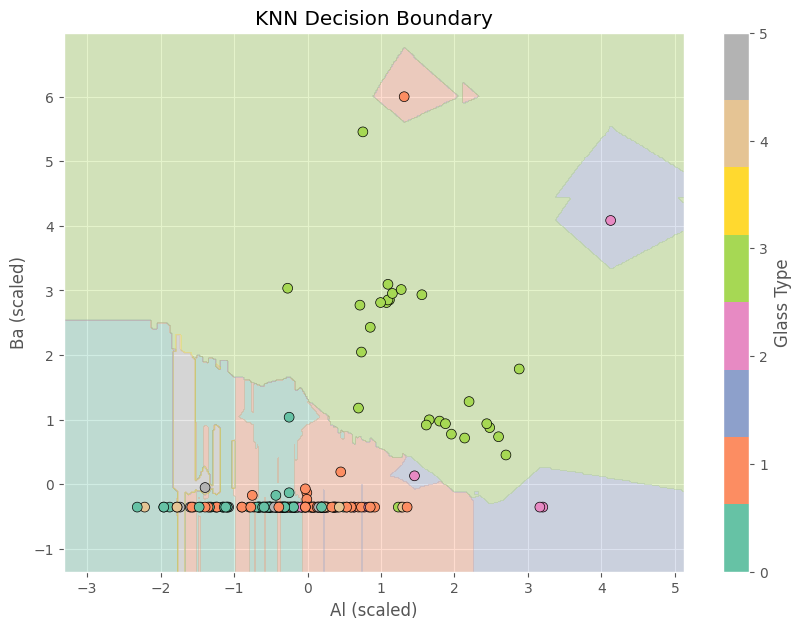

In [62]:
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')  # background colors = decision regions
scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], 
                       c=y_2d, cmap='Set2', edgecolor='black', s=50)
plt.xlabel(f'{feature1} (scaled)')
plt.ylabel(f'{feature2} (scaled)')
plt.title('KNN Decision Boundary')
plt.colorbar(scatter, label='Glass Type')
plt.show()

---
## ✏️ Exercise 4: KNN Regressor
Apply KNN for regression on a continuous target.

**Tasks:**
1. Use `Refractive Index (RI)` as target, rest as features
2. Train KNeighborsRegressor
3. Evaluate with MSE, MAE, R²
4. Plot actual vs predicted values

In [63]:
# YOUR CODE HERE
X_reg = df.drop(columns=['RI'])
y_reg = df['RI']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [65]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [66]:
knn_reg = KNeighborsRegressor(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

In [67]:
knn_reg.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [68]:
y_pred = knn_reg.predict(
    X_test_scaled
)

In [70]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [71]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.0009355898654467726
MSE: 2.3745097643186463e-06
RMSE: 0.0015409444390758046
R2 Score: 0.639005391662252


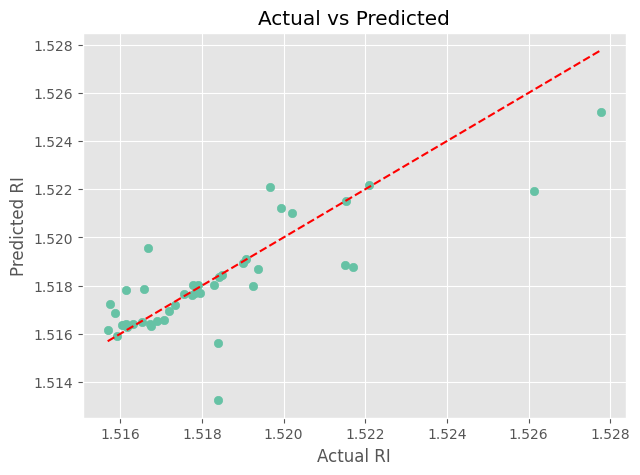

In [73]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual RI")
plt.ylabel("Predicted RI")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()

---
## ✏️ Exercise 5: Curse of Dimensionality Experiment
Show how adding random noise features degrades KNN.

**Tasks:**
1. Start with original 9 features → record accuracy
2. Add 10 random noise columns → accuracy
3. Add 50 random noise columns → accuracy
4. Add 100 random noise columns → accuracy
5. Plot #features vs accuracy to visualize the curse

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Original Features
X_original = X.copy()
y_original = y.copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_original
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="manhattan",
    weights="distance"
)

knn.fit(X_train_scaled, y_train)

# Prediction
y_pred = knn.predict(X_test_scaled)

acc_original = accuracy_score(y_test, y_pred)

print("Original Features:", X_original.shape[1])
print("Accuracy:", acc_original)

Original Features: 9
Accuracy: 0.7674418604651163


In [77]:
import numpy as np

def evaluate_knn(X_data, y_data):

    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.2,
        random_state=42,
        stratify=y_data
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = KNeighborsClassifier(
        n_neighbors=3,
        metric="manhattan",
        weights="distance"
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return accuracy_score(y_test, pred)

In [78]:
# Add 10 random noise features
np.random.seed(42)

noise10 = np.random.randn(len(X), 10)

X10 = np.hstack((X.values, noise10))

acc10 = evaluate_knn(X10, y)

print("19 Features Accuracy:", acc10)

19 Features Accuracy: 0.627906976744186


In [79]:
noise50 = np.random.randn(len(X), 50)

X50 = np.hstack([X.values, noise50])

acc50 = evaluate_knn(X50, y)

print("59 Features Accuracy:", acc50)

59 Features Accuracy: 0.46511627906976744


In [80]:
noise100 = np.random.randn(len(X), 100)

X100 = np.hstack([X.values, noise100])

acc100 = evaluate_knn(X100, y)

print("109 Features Accuracy:", acc100)

109 Features Accuracy: 0.4418604651162791


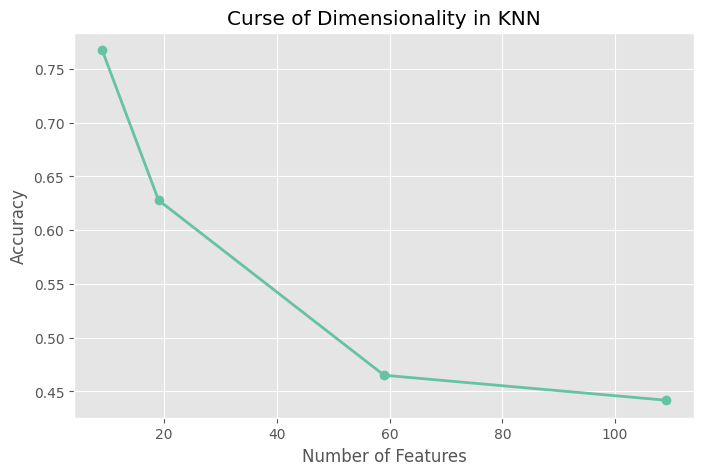

In [81]:
import matplotlib.pyplot as plt

features = [9, 19, 59, 109]
accuracies = [acc_original, acc10, acc50, acc100]

plt.figure(figsize=(8,5))

plt.plot(features, accuracies, marker='o', linewidth=2)

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Curse of Dimensionality in KNN")
plt.grid(True)

plt.show()

---
## 📝 Key Takeaways
1. Scaling improvement (% gain): ...
2. Best hyperparams from GridSearch: ...
3. KNN Regressor R² score: ...
4. Curse of dimensionality impact: ...